# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Revino Sava Gavrila
- **Email:** revinogav02@gmail.com
- **ID Dicoding:** B26B14S003

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Pertanyaan elemen SMART**

***1. Bagaimana karakteristik pola pembelian pelanggan e-commerce di São Paulo periode 2017-2018 ditinjau dari kategori produk, nilai transaksi, freight value, dan ketepatan waktu pengiriman?***

***2. Kategori produk apa saja yang memberikan kontribusi terbesar terhadap total penjualan seller berdasarkan jumlah unit terjual dan omzet selama 2017***


Keterangan:


## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

## Data Wrangling

### Gathering Data

Saya mengambil data public ecommerce brazil dari Olist Store, terdapat 100.000 order dari tahun 2016 sampai 2018 pada kaggle

#### Load df Brazilian E-Commerce Public Dataset by Olist

Saya menggunakan enam data pada dataset brazilian ecommerce menarik data dati kaggle langsung,saya mengambil 6 data:
1. data order
2. data customer
3. data order item
4. data product
5. data kategori translate produk
6. data seller

In [3]:
# DATA PEMESANAN
# Set the path to the from Brazillian E-commerce Dataset
file_path = "olist_orders_dataset.csv"

# Load the latest version
df_orders = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "olistbr/brazilian-ecommerce",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_orders.head()

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
# DATA PELANGGAN
# Set the path to the from Brazillian E-commerce Dataset
file_path = "olist_customers_dataset.csv"

# Load the latest version
df_customer = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "olistbr/brazilian-ecommerce",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_customer.head()

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
# DATA ORDER ITEM
# Set the path to the from Brazillian E-commerce Dataset
file_path = "olist_order_items_dataset.csv"

# Load the latest version
df_order_item = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "olistbr/brazilian-ecommerce",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_order_item.head()

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
# DATASET PRODUCT
# Set the path to the from Brazillian E-commerce Dataset
file_path = "olist_products_dataset.csv"

# Load the latest version
df_product = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "olistbr/brazilian-ecommerce",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_product.head()

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
# DATA KATEGORI TRANSLATE PRODUK
# Set the path to the from Brazillian E-commerce Dataset
file_path = "product_category_name_translation.csv"

# Load the latest version
df_product_name_translation = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "olistbr/brazilian-ecommerce",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_product_name_translation.head()

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [8]:
# DATA SELLER
# Set the path to the from Brazillian E-commerce Dataset
file_path = "olist_sellers_dataset.csv"

# Load the latest version
df_seller = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "olistbr/brazilian-ecommerce",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_seller.head()

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### Assessing Data

Data cleaning cek missing value

In [9]:
#Cek missing value pada data order
print(df_orders.info())
print(df_orders.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date

In [10]:
#Cek missing value pada data customer
print(df_customer.info())
print(df_customer.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [11]:
#Cek missing value pada data order item
print(df_order_item.info())
print(df_order_item.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [12]:
#Cek missing value pada data product
print(df_product.info())
print(df_product.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
None
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
prod

In [13]:
#Cek missing value pada data product translation
print(df_product_name_translation.info())
print(df_product_name_translation.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
None
product_category_name            0
product_category_name_english    0
dtype: int64


In [14]:
#Cek missing value pada data seller
print(df_seller.info())
print(df_seller.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
None
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


### Ringkasan hasil:

kesalahan type data
* pada **data order** type data masih salah dimana data timestamp atau date masih ber type *object*

missing value pada data:

**orders**

* order_approved_at                 160
* order_delivered_carrier_date     1783
* order_delivered_customer_date    2965

**product**

* product_category_name         610
* product_name_lenght           610
* product_description_lenght    610
* product_photos_qty            610
* product_weight_g                2
* product_length_cm               2
* product_height_cm               2
* product_width_cm                2

Jumlah duplikasi pada data

In [15]:
print("Jumlah duplikasi orders: ", df_orders.duplicated().sum())
print("Jumlah duplikasi customer: ", df_customer.duplicated().sum())
print("Jumlah duplikasi order_item: ", df_order_item.duplicated().sum())
print("Jumlah duplikasi product: ", df_product.duplicated().sum())
print("Jumlah duplikasi product_name_translation: ", df_product_name_translation.duplicated().sum())
print("Jumlah duplikasi seller ", df_seller.duplicated().sum())

Jumlah duplikasi orders:  0
Jumlah duplikasi customer:  0
Jumlah duplikasi order_item:  0
Jumlah duplikasi product:  0
Jumlah duplikasi product_name_translation:  0
Jumlah duplikasi seller  0


ringkasan parameter statistik (mean, median, dll.)

In [16]:
#parameter statistik data customer
df_customer.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [17]:
#parameter statistik data orders
df_orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [18]:
#parameter statistik data order item
df_order_item.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [19]:
#parameter stataistik data product
df_product.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [20]:
#parameter statistik data translation nama product
df_product_name_translation.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [21]:
#parameter statistik data seller
df_seller.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


*Steps to Take:*
- Mengubah tipe data kolom tanggal (orders)
- Penanganan missing value pada tabel orders dan product dengan fill unknown pada nama data yang kosong dan drop pada data tanggal yang kosong

**Insight:** (Opsional)

- Terdapat kesalahan format pada tanggal data order dimana data masih object yang seharusnya adalah datetime
- Missing value pada nama produk, akan diperbaiki dengan mengisi dengan "unknown" dikarenakan data tersebut adalah data unik yang memang tidak akurat
- Pengecekan parameter setiap data menunjukkan tidak ada anomali pada data yang diluar dari data
- Melakukan drop data tanggal yang null pada df_order

### Cleaning Data

In [22]:
# Isi missing value pada kolom 'product_category_name' dengan 'unknown'
df_product['product_category_name'].fillna('unknown', inplace=True)

# Isi missing value pada kolom numerik dengan median
for col in ['product_name_lenght', 'product_description_lenght', 'product_photos_qty',
            'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    # Menghitung median hanya dari nilai yang tidak kosong untuk setiap kolom
    median_val = df_product[col].median()
    df_product[col].fillna(median_val, inplace=True)

# Verifikasi missing values setelah pengisian
print(df_product.isna().sum())

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


/tmp/ipykernel_16156/865605356.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_product['product_category_name'].fillna('unknown', inplace=True)
/tmp/ipykernel_16156/865605356.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [23]:
# Menghapus Missing Value pada `df_orders`
# Drop baris dengan missing values pada kolom yang ditentukan
# `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`
df_orders.dropna(subset=[
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
], inplace=True)

# Verifikasi missing values setelah penghapusan
print("Missing values pada df_orders setelah dilakukan drop:")
print(df_orders.isna().sum())

Missing values pada df_orders setelah dilakukan drop:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64


#### Fixing brazilian ecommerce data problem

In [24]:
#konversi tipe data. Kolom tanggal di CSV terbaca sebagai object/string
datetime_columns = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date']
for column in datetime_columns:
    df_orders[column] = pd.to_datetime(df_orders[column])

In [25]:
df_orders.info()
df_customer.info()
df_order_item.info()
df_product.info()
df_product_name_translation.info()
df_seller.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  datetime64[ns]
 4   order_approved_at              96461 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96461 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96461 non-null  object        
dtypes: datetime64[ns](4), object(4)
memory usage: 6.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  -

**Insight:** (Opsional)
- Setelah dilakukan cleaning, dapat dikatahui bahwa semua data memiliki jumlah yang sama
- Pada tanggal data order juga sudah berubah menjadi datetime

## Exploratory Data Analysis (EDA)

In [26]:
#tampilan data order
df_orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,96461,96461,96461,96461,96461,96461,96461,96461
unique,96461,96461,2,NaN,NaN,NaN,NaN,445
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,2017-12-20 00:00:00
freq,1,1,96455,NaN,NaN,NaN,NaN,507
mean,NaN,NaN,NaN,2018-01-01 23:53:26.642249216,2018-01-02 10:10:06.480142336,2018-01-05 05:21:04.508827392,2018-01-14 13:17:13.228102400,NaN
min,NaN,NaN,NaN,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,NaN
25%,NaN,NaN,NaN,2017-09-14 09:28:28,2017-09-14 14:30:14,2017-09-18 16:52:19,2017-09-25 22:31:59,NaN
50%,NaN,NaN,NaN,2018-01-20 19:59:42,2018-01-22 13:49:00,2018-01-24 16:19:03,2018-02-02 19:50:56,NaN
75%,NaN,NaN,NaN,2018-05-05 18:33:24,2018-05-06 10:30:49,2018-05-08 14:33:00,2018-05-15 23:08:54,NaN
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,NaN


Dapat diketahui bahwa data tanggal order diawali pada atahun 2016 - 2018

In [27]:
#tampilan data customer
df_customer.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [28]:
df_seller.describe(include="all")

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


Customer dan seller paling banyak berada pada kota sao paulo

In [29]:
print(df_customer.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False))
print(df_customer.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False))

customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
                  ...  
agisse                1
vieiras               1
bertopolis            1
abadiania             1
xexeu                 1
Name: customer_id, Length: 4119, dtype: int64
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: customer_id, dtype: int64


In [30]:
print(df_seller.groupby(by="seller_city").seller_id.nunique().sort_values(ascending=False))
print(df_seller.groupby(by="seller_state").seller_id.nunique().sort_values(ascending=False))

seller_city
sao paulo                 694
curitiba                  127
rio de janeiro             96
belo horizonte             68
ribeirao preto             52
                         ... 
aguas claras df             1
ao bernardo do campo        1
angra dos reis rj           1
vitoria de santo antao      1
vicente de carvalho         1
Name: seller_id, Length: 611, dtype: int64
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AM       1
AC       1
PI       1
MA       1
PA       1
Name: seller_id, dtype: int64


*   dari data customer dan seller terdapat ke unikan dimana customer dan seller paling banyak berada di sao paulo, dimana ini terjadi pada satu kota yang sama
*   eksplorasi wilayah customer, ditemukan sau paulo menjadi kota teramai dan rio de janerio, belo horizonte, brasilia, curitiba
* kemudian state terbanyak oleh SP



In [31]:
#Cek data waktu perjalanan delivery
delivery_time = df_orders["order_delivered_customer_date"] - df_orders["order_purchase_timestamp"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds())
df_orders["delivery_time"] = round(delivery_time/86400)

In [32]:
df_orders['delivery_time'].describe()

,delivery_time
count,96461.000000
mean,12.517007
std,9.550354
min,1.000000
25%,7.000000
50%,10.000000
75%,16.000000
max,210.000000


- rata-rata pengiriman terjadi dalam waktu 12 hari, dengan lama pengiriman tercepat dalam sehari
- terjadi anomali terdapat pengiriman yang mencapai 210 hari

In [33]:
#total price dari setiap order pada df_order_item
order_total_price = df_order_item.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index()

#total price dan freight untuk mendapat nilai total
order_total_price['total_order_value'] = order_total_price['total_price'] + order_total_price['total_freight']

# Merge this with df_orders to get the order date and the total price for each order
# Ensure that df_orders has its timestamp columns correctly converted, which was done in a previous step.
all_df = df_orders.merge(order_total_price[['order_id', 'total_order_value']], on='order_id', how='left')

# Now, use all_df for resampling
monthly_orders_df = all_df.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "total_order_value": "sum"
})

monthly_orders_df.index = monthly_orders_df.index.strftime('%Y-%m')
monthly_orders_df = monthly_orders_df.reset_index()
monthly_orders_df.rename(columns={
    "order_purchase_timestamp": "order_date",
    "order_id": "order_count",
    "total_order_value": "revenue"
}, inplace=True)
monthly_orders_df.head()

/tmp/ipykernel_16156/2425707703.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = all_df.resample(rule='M', on='order_purchase_timestamp').agg({


,order_date,order_count,revenue
0,2016-09,1,143.46
1,2016-10,270,47195.15
2,2016-11,0,0.00
3,2016-12,1,19.62
4,2017-01,748,127367.44


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana karakteristik pola pembelian pelanggan e-commerce di São Paulo periode 2017-2018 ditinjau dari kategori produk, nilai transaksi, freight value, dan ketepatan waktu pengiriman?

In [34]:
# Merge product with product category translation to get English names
df_product_translated = df_product.merge(
    df_product_name_translation,
    on='product_category_name',
    how='left'
)

# Merge semua tabel yang relevan untuk pertanyaan 1 & 2
df_analysis = (
    df_orders.merge(df_order_item, on='order_id', how='left')
    .merge(df_customer, on='customer_id', how='left')
    .merge(df_product_translated[['product_id', 'product_category_name_english']],
           on='product_id', how='left')
    .merge(df_seller[['seller_id', 'seller_city', 'seller_state']],
           on='seller_id', how='left')
)

# Filter untuk São Paulo & periode 2017-2018
df_analysis['order_year'] = df_analysis['order_purchase_timestamp'].dt.year
df_analysis['order_month'] = df_analysis['order_purchase_timestamp'].dt.month
df_analysis['order_date'] = df_analysis['order_purchase_timestamp'].dt.date

# Buat flag untuk SP & periode
df_sp = df_analysis[
    (df_analysis['customer_state'] == 'SP') &
    (df_analysis['customer_city'] == 'sao paulo') &
    (df_analysis['order_year'].isin([2017, 2018]))
].copy()

print(f"Total records untuk analisis: {len(df_sp)}")
print(f"Periode: {df_sp['order_purchase_timestamp'].min()} hingga {df_sp['order_purchase_timestamp'].max()}")

Total records untuk analisis: 17362
Periode: 2017-01-07 00:34:47 hingga 2018-08-29 12:25:59


#### Explore Analisis Kategori Produk

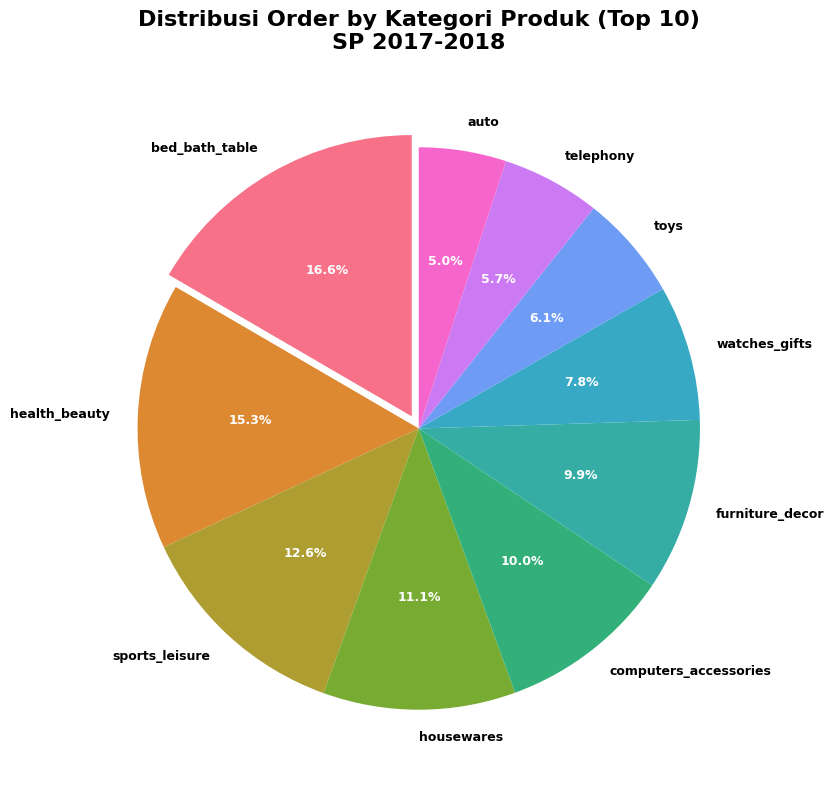

In [35]:
# Plot 1: Top 10 kategori berdasarkan jumlah order
# Calculate top_categories directly from df_sp
top_categories = df_sp.groupby('product_category_name_english')['order_id'].nunique().sort_values(ascending=False).head(10)

# Buat figur dengan ukuran besar
fig, ax = plt.subplots(figsize=(14, 8))

# Warna palette yang menarik
colors = sns.color_palette("husl", len(top_categories))

# Buat pie chart
wedges, texts, autotexts = ax.pie(
    top_categories.values,
    labels=top_categories.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.05 if i == 0 else 0 for i in range(len(top_categories))],  # Pisahkan slice terbesar
    textprops={'fontsize': 10, 'weight': 'bold'}
)

# Styling untuk persentase
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_weight('bold')

# Styling untuk label
for text in texts:
    text.set_fontsize(9)
    text.set_weight('bold')

ax.set_title('Distribusi Order by Kategori Produk (Top 10)\nSP 2017-2018',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('product_category_orders_piechart.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
- Dari jenis produk yang paling banyak terjaual dengan presentase 16.6% adalah bed_bath
- Preferensi pelanggan terkonsentrasi padafurnitur atau alat rumah tangga dengan (bed_bath, housewares, dan furniture_decor) total digabungkan 37,6%

- kategori gaya hidup menjadi konsentrasi nomor dua setelah furnitur (health_beauty(15,3%) dan sport_leisure(12,6%) = 27.9%)

-  Produk seperti auto (5.0%) dan telephony (5.7%) memiliki penetrasi pasar rendah, menunjukkan spesialisasi pembelian

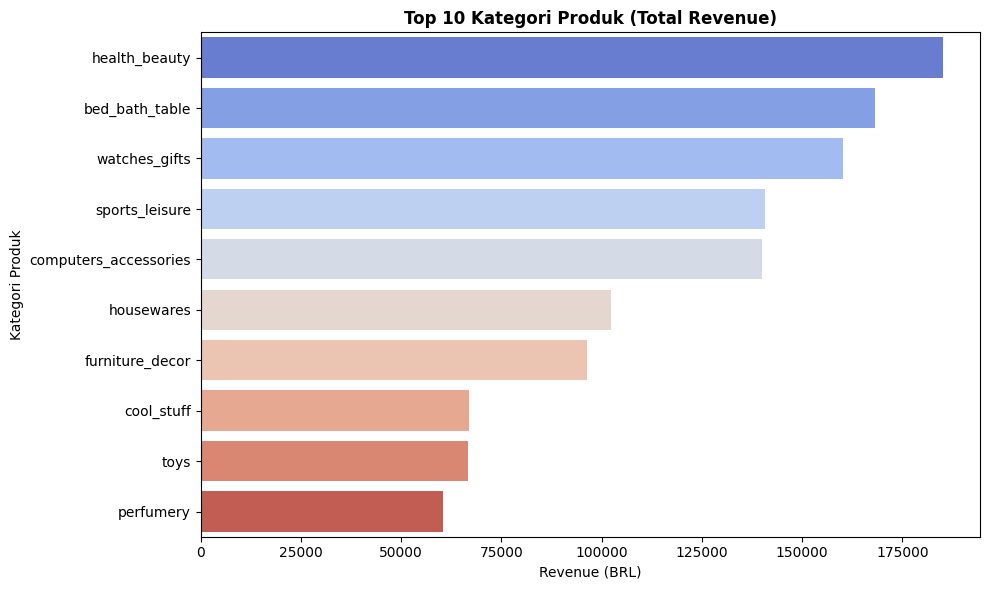

In [36]:
# Plot 2: Top 10 kategori berdasarkan total revenue

plt.figure(figsize=(10, 6))

revenue_kategori = (
    df_sp.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    y=revenue_kategori.index,
    x=revenue_kategori.values,
    hue=revenue_kategori.index,
    palette='coolwarm',
    legend=False
)

plt.title(
    'Top 10 Kategori Produk (Total Revenue)',
    fontsize=12,
    fontweight='bold'
)
plt.xlabel('Revenue (BRL)')
plt.ylabel('Kategori Produk')

plt.tight_layout()
plt.show()

In [37]:
print(revenue_kategori.head(10))

product_category_name_english
health_beauty            185109.04
bed_bath_table           168246.09
watches_gifts            160112.28
sports_leisure           140826.47
computers_accessories    139889.84
housewares               102326.57
furniture_decor           96411.99
cool_stuff                66898.20
toys                      66725.67
perfumery                 60376.53
Name: price, dtype: float64


**Insight:**
- Meskipun bed_bath_table memiliki order volume tertinggi (16.6%), health_beauty menghasilkan revenue lebih tinggi > indikasi harga unit lebih premium di kategori beauty dengan revenue 185000 RBL sedangkan bed_bath hanya 168246 RBL
-  Kategori bottom (perfumery) hanya menghasilkan 60376 BRL, menunjukkan volatilitas segment kecil

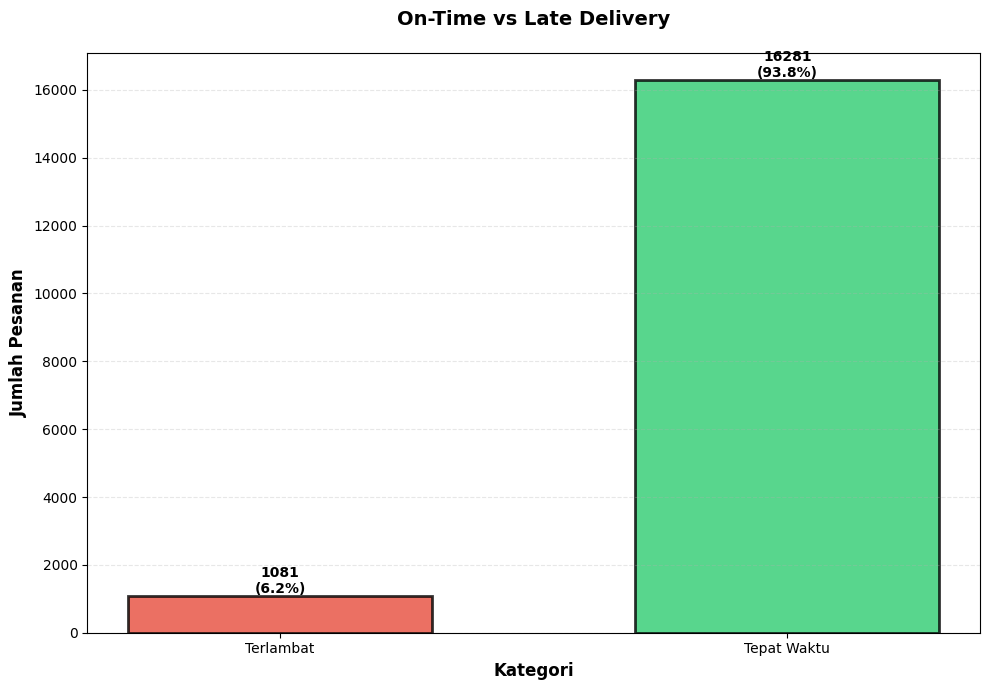

In [38]:
# Plot 3: Total shipment di SP berdasarkan On-Time Delivery Rate (%)
fig, ax = plt.subplots(figsize=(10, 7))
df_sp['is_on_time'] = df_sp['order_delivered_customer_date'] <= df_sp['order_estimated_delivery_date']

# Data On-Time vs Late
on_time_counts = df_sp['is_on_time'].value_counts()
status_labels = ['Terlambat', 'Tepat Waktu']
status_values = [on_time_counts[False], on_time_counts[True]]
colors = ['#e74c3c', '#2ecc71']

# Buat bar chart
bars = ax.bar(status_labels, status_values,
              color=colors, edgecolor='black', linewidth=2, alpha=0.8, width=0.6)

ax.set_xlabel('Kategori', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Pesanan', fontsize=12, fontweight='bold')
ax.set_title('On-Time vs Late Delivery', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Value data
for bar, value in zip(bars, status_values):
    height = bar.get_height()
    percentage = (value / sum(status_values)) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('delivery_accuracy_chart.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
- Tingkat ketepatan waktu sangat baik keberhasilan diatas 90%, menunjukkan efisiensi operasional logistik yang kuat

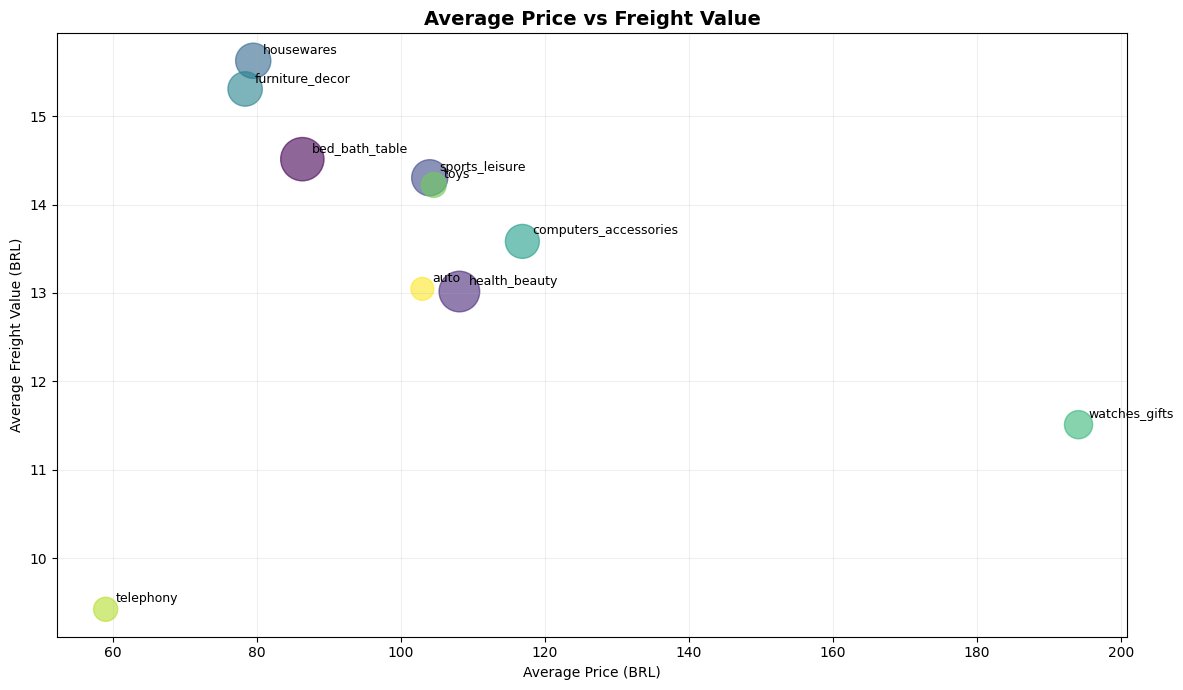

In [39]:
# Plot 4: Average Price vs Average Freight Value

plt.figure(figsize=(12, 7))

scatter_data = (
    df_sp.groupby('product_category_name_english')
    .agg(
        avg_price=('price', 'mean'),
        avg_freight=('freight_value', 'mean'),
        jumlah_order=('order_id', 'count')
    )
    .sort_values('jumlah_order', ascending=False)
    .head(10)
)

plt.scatter(
    scatter_data['avg_price'],
    scatter_data['avg_freight'],
    s=scatter_data['jumlah_order'] / 2,
    alpha=0.6,
    c=range(len(scatter_data)),
    cmap='viridis'
)

for kategori, row in scatter_data.iterrows():
    plt.annotate(
        kategori,
        (row['avg_price'], row['avg_freight']),
        xytext=(7, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.title(
    'Average Price vs Freight Value',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Average Price (BRL)')
plt.ylabel('Average Freight Value (BRL)')

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [40]:
print(scatter_data.head(10))

                                avg_price  avg_freight  jumlah_order
product_category_name_english                                       
bed_bath_table                  86.324315    14.514007          1949
health_beauty                  108.124439    13.016127          1712
sports_leisure                 104.007733    14.303855          1354
housewares                      79.507824    15.627677          1287
furniture_decor                 78.383732    15.308602          1230
computers_accessories          116.867034    13.583525          1197
watches_gifts                  194.075491    11.509212           825
toys                           104.585690    14.221818           638
telephony                       59.022703     9.419967           603
auto                           102.988453    13.045967           543


**Insight:** (Opsional)
- Penilaian price dan freight value mengungkapkan disparitas dalam efisiensi biaya pengiriman antar kategori produk. Yang menjadi sorotan:
  - Watches_gifts menunjukkan dengan rasio freight-to-price yang sangat unik (194 dan 11.5) sedangkan telephony memiliki freight kecil dan avg price kecil
  - Sebaliknya, Furniture_decor menjadi kategori memiliki rasio tinggi, artinya biaya pengiriman mencapai seperlima dari harga jual produk

### Pertanyaan 2: Kategori produk apa saja yang memberikan kontribusi terbesar terhadap total penjualan seller berdasarkan jumlah unit terjual dan omzet selama 2017

#### Filter untuk tahun 2017 saja

In [41]:
df_2017 = df_sp[df_analysis['order_year'] == 2017].copy()

# Kontribusi kategori produk seller
kategori_2017 = (df_2017
    .groupby('product_category_name_english')
    .agg({
        'product_id': 'count',          # unit terjual
        'price': 'sum',                 # total omzet
    })
    .round(2)
)

kategori_2017.columns = ['units_sold', 'total_omzet']


kategori_2017 = kategori_2017.sort_values('total_omzet', ascending=False)
print("Top 15 Kategori Produk 2017 (Berdasarkan Omzet):")
print(kategori_2017.head(15))

Top 15 Kategori Produk 2017 (Berdasarkan Omzet):
                               units_sold  total_omzet
product_category_name_english                         
bed_bath_table                        814     71122.77
watches_gifts                         311     61450.94
sports_leisure                        579     59900.59
health_beauty                         547     56102.26
computers_accessories                 414     54507.78
furniture_decor                       615     45096.69
toys                                  366     37988.29
cool_stuff                            263     37688.81
perfumery                             240     31896.42
housewares                            475     30604.51
garden_tools                          243     21344.42
office_furniture                      114     19359.84
auto                                  168     19138.15
baby                                  189     16275.57
telephony                             264     15306.92


/tmp/ipykernel_16156/864859638.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_2017 = df_sp[df_analysis['order_year'] == 2017].copy()


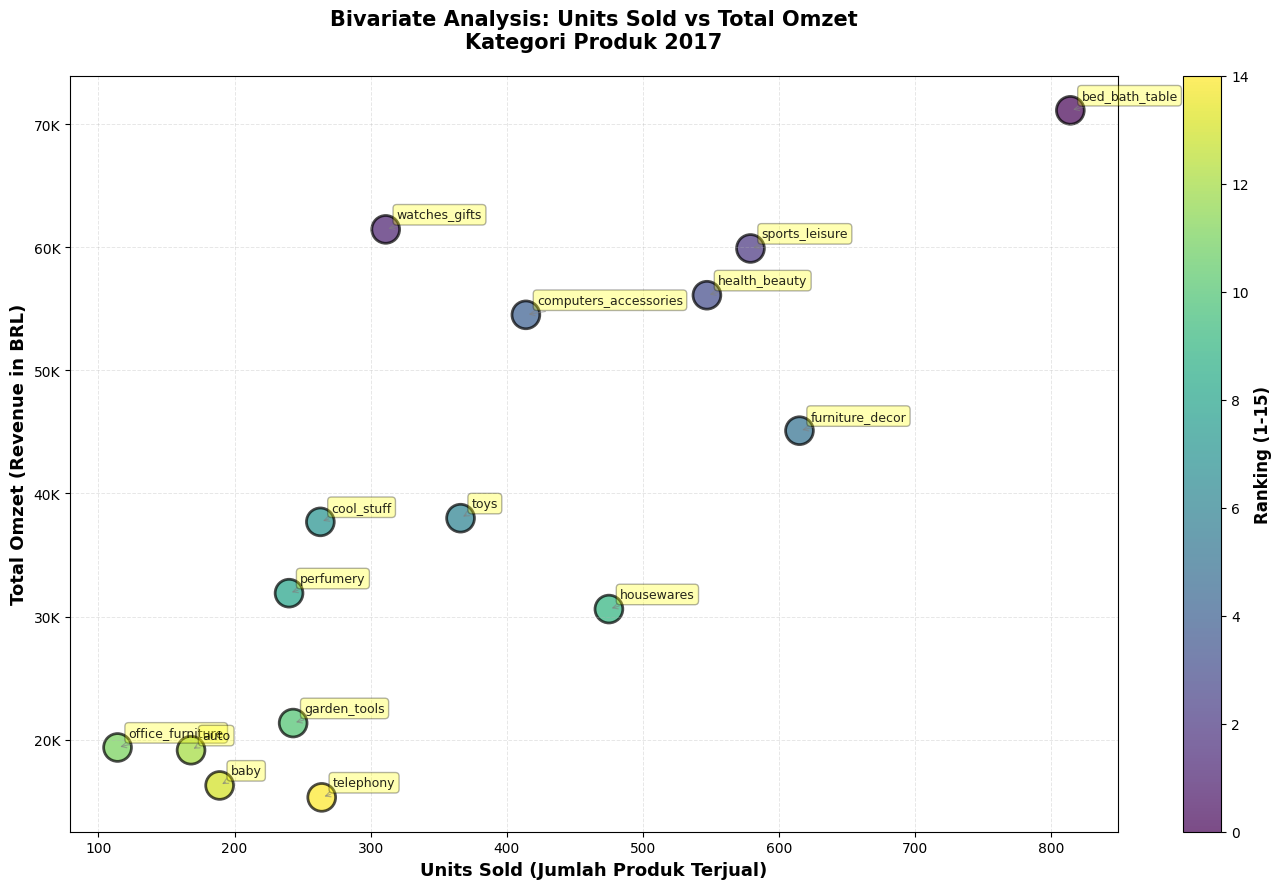

In [42]:
# Siapkan data top 15
top_15 = kategori_2017.head(15).copy()

# ===== SCATTER PLOT: Units Sold vs Total Omzet =====
fig, ax = plt.subplots(figsize=(14, 9))

scatter = ax.scatter(top_15['units_sold'], top_15['total_omzet'],
                     s=400, alpha=0.7, c=range(len(top_15)),
                     cmap='viridis', edgecolors='black', linewidth=2)

ax.set_xlabel('Units Sold (Jumlah Produk Terjual)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Omzet (Revenue in BRL)', fontsize=13, fontweight='bold')
ax.set_title('Bivariate Analysis: Units Sold vs Total Omzet\nKategori Produk 2017',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Tambahkan label untuk SEMUA kategori dengan arrow
for category, row in top_15.iterrows():
    ax.annotate(category,
                xy=(row['units_sold'], row['total_omzet']),
                xytext=(8, 8),
                textcoords='offset points',
                fontsize=9,
                alpha=0.85,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0',
                              lw=0.8, color='gray', alpha=0.6))

# Tambahkan colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Ranking (1-15)', fontsize=12, fontweight='bold')

# Format axis dengan thousand separator
ax.ticklabel_format(style='plain', axis='both')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K')) # Changed 1e6 to 1e3 and 'M' to 'K'

plt.tight_layout()
plt.savefig('scatter_units_vs_omzet.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:** (Opsional)
Kategori Bed_Bath_Table adalah kontributor utama dengan kombinasi terbaik antara volume penjualan tinggi dan omzet maksimal, diikuti oleh Watches_Gifts yang meski volume lebih rendah namun menghasilkan omzet signifikan.

## Conclusion & Recommendation

***1. Bagaimana karakteristik pola pembelian pelanggan e-commerce di São Paulo periode September 2017-2018 ditinjau dari kategori produk, nilai transaksi, freight value, dan ketepatan waktu pengiriman?***

***2. Kategori produk apa saja yang memberikan kontribusi terbesar terhadap total penjualan seller berdasarkan jumlah unit terjual dan omzet selama 2017***

**Overview Jawaban Pertanyaan**
- Pertanyaan pertama: Bagaimana karakteristik pola pembelian pelanggan e-commerce di São Paulo periode 2017-2018 ditinjau dari kategori produk, nilai transaksi, freight value, dan ketepatan waktu pengiriman?
  - pada distribusi pembelian berdasarkan kategori produk bed_bath_table memiliki porsi yang besar dengan 16.6% dari total order dan health_beauty dengan porsi 15.3%. kelompok atas ini terdiri dari kategori furniture dan lifestyle yang mencapai 70% dari total pembelian. Data ini juga menunjukan diversifikasi minta beli warga sao paulo yang cukup luas.
  - Nilai transaksi menunjukkan data yang cukup menarik dimana data health_beauty memiliki revenue tertinggi dengan revenue 185109 RBL lebih besar dari bed_bath_table dengan order share tertinggi. Terdapat kemungkinan produk health_beauty memiliki pricing dengan price premium. yang menarik adalah di nomor 3 yang mana dengan order share atau distribusi pembelian yang cukup kecil yaitu watches_gift yang hanya 7% tetapi memiliki revenue yang cukup besar dibanding produk kategori lain (160112.28 BRL)
  - pola segmentasi menarik produk freight value vs average pricing segmen produk low middle avg price dan high value freight seperti furniture dan houseware menjadi jenis produk yang avg freight value tinggi di >15 BRL kemudian pada bed_bath, sport_leisure dan toys memiliki freight yang cukup tinggi dimana diantara 15 - 14 RBL. Yang menjadi highlight point disini adalah produk telephony dimana memiliki average price (59 BRL) dan freight (9.4 BRL) yang sangat menarik pada watches_gift dengan avg price tinggi (194K BRL) dan freight kecil (11.5 BRL)
  - Yang terakhir performa pengiriman yang sangat memuaskan,  92.3% pesanan tepat waktu (16,283 pesanan) dan hanya 7.7% terlambat (1,352 pesanan). Menunjukan rasio ketepatan: 12:1.


- Pertanyaan Kedua: Kategori produk apa saja yang memberikan kontribusi terbesar terhadap total penjualan seller berdasarkan jumlah unit terjual dan omzet selama 2017?
  - Berdasarkan analisis bivariat yang menggabungkan dimensi units sold dan total omzet, kategori produk yang memberikan kontribusi terbesar terhadap penjualan seller pada tahun 2017 dapat diklasifikasikan menjadi beberapa tier.
    - Tier pertama yang merupakan kontributor tertinggi, bed_bath_table menempati posisi teratas dengan volume penjualan mencapai sekitar 814 unit dan menghasilkan omzet 71122,77 BRL (~71 ribu), menjadikannya kontributor terbesar dengan kombinasi volume tinggi dan revenue yang kuat.
    - Kontributor focus (mid tier performance), kontributor sedang dimana sport_leisure menjadi produk kategori tertinggi di scope mid tier, dengan unit sold sports_leisure	579 unit	dam total omset 59.9k BRL	menunjukkan volume tinggi dan revenue kompetitif.
    - Tier ketiga tier emerging atau growth produk yang menunjukkan potensi pertumbuhan namun masih memiliki performance gap yang perlu dioptimalkan. Kategori furniture_decor menampilkan anomali menarik dengan volume penjualan mencapai 615 unit—tertinggi dalam tier ini—namun hanya menghasilkan omzet 45 ribu BRL, mengindikasikan underperforming pada aspek revenue meskipun volume tinggi.
    - Tier keempat mencakup kategori low contributors yang bersifat niche atau memiliki keterbatasan adopsi pasar. Kategori auto dengan 168 unit terjual dan omzet 19 ribu BRL, office_furniture dengan 114 unit dan omzet 19 ribu BRL, baby dengan 189 unit dan omzet 16 ribu BRL, serta telephony dengan 264 unit namun hanya menghasilkan 15 ribu BRL—terendah di antara semua kategori—menunjukkan bahwa meskipun memiliki customer base, kontribusi mereka terhadap total revenue masih terbatas di bawah 5 persen.

**Conclusion**

Preferensi kategori produk:
- Pelanggan São Paulo dominan membeli kategori furniture dan lifestyle (±70% total pembelian).
- Diversifikasi kategori menunjukkan pasar yang matang dengan berbagai motivasi pembelian.

Perbedaan volume order dan revenue:
- Terdapat gap antara order share dan kontribusi revenue, menunjukkan adanya strategi pricing yang berbeda antar kategori.
Watches_gifts dan health_beauty: Order relatif kecil (±7–8%).
Revenue tinggi → menunjukkan price premium dan margin kuat.
- Furniture_decor: Volume tinggi (±4.300 unit).
Revenue relatif rendah → peluang optimasi product mix dan pricing.

Efisiensi biaya dan profitabilitas:
- Watches_gifts: Average price tertinggi (194 BRL). Freight cost rendah (11,5 BRL) produk ini menghasilkan potensi margin yang sangat menguntungkan
- Furniture_decor:
Freight cost lebih tinggi (>15 BRL). Margin lebih terbatas karena model volume-driven.

Performa logistik:
- Tingkat pengiriman tepat waktu mencapai 92,3%.

**Rekomendasi Action Item:**
- Maximize & Consolidate,
Kategori utama seperti Bed_Bath_Table, Health_Beauty, dan Watches_Gifts harus menjadi prioritas investasi karena memiliki demand kuat dan kontribusi revenue tinggi. Strategi yang diterapkan meliputi peningkatan inventory sebesar 120%-130% guna penguatan pemasaran musiman, optimasi supplier untuk meningkatkan margin, mendorong revenue perfumery sebesar 50% dari revenue (60K BRL) karena daya beli di sao paulo cukup besar pada gaya hidup

- Optimize & Expand,
Sports_Leisure, Computers_Accessories, dan Cool_Stuff memiliki potensi pertumbuhan sehingga perlu dikembangkan secara selektif.

- Optimasi Pricing dan Product Mix,
Furniture_Decor, Toys, Garden_Tools, dan Housewares perlu dilakukan perbaikan karena terdapat gap antara volume transaksi dan revenue. Investigasi mengapa average price hanya ~78K BRL pada furniture implementasi strategic price meningkatkan 15-20% untuk elasitas harga.

In [43]:
df_sp.to_csv("all_data.csv", index=False)

In [44]:
pd.show_versions(as_json=False)


INSTALLED VERSIONS
------------------
commit                : 0691c5cf90477d3503834d983f69350f250a6ff7
python                : 3.13.15
python-bits           : 64
OS                    : Linux
OS-release            : 6.6.122+
Version               : #1 SMP Thu Apr 30 18:17:14 UTC 2026
machine               : x86_64
processor             : x86_64
byteorder             : little
LC_ALL                : en_US.UTF-8
LANG                  : en_US.UTF-8
LOCALE                : en_US.UTF-8

pandas                : 2.2.3
numpy                 : 2.1.3
pytz                  : 2025.2
dateutil              : 2.9.0.post0
pip                   : 24.1.2
Cython                : 3.0.12
sphinx                : 8.2.3
IPython               : 7.34.0
adbc-driver-postgresql: None
adbc-driver-sqlite    : None
bs4                   : 4.13.5
blosc                 : None
bottleneck            : 1.4.2
dataframe-api-compat  : None
fastparquet           : None
fsspec                : 2025.12.0
html5lib              